# Checkpoint Week 3 — Decision Trees & Ensembles

Vul alle cellen in en push dit bestand naar je repo. De automatische checks (GitHub Actions) voeren dit notebook uit en controleren of alle **variabelen met de gevraagde namen** bestaan en correct zijn.

**BELANGRIJK**: gebruik exact de genoemde variabelennamen (`accuracy_voting`, `y_pred_voting`, `accuracy_bagging`, `accuracy_single_tree`, `y_pred_ada`, `accuracy_ada`, `f1_ada`, `y_pred_xgb`, `accuracy_xgb`, `f1_xgb`, `antwoord_tree_variatie`, `antwoord_ensemble`), anders faalt de controle.

**Gebruik in elke oefening `test_size=0.2` en `random_state=42`** bij de train/test-split, anders kunnen de checks afwijken.

---
# Oefening 1 — Decision Trees op de Wine dataset

- Laad de wine dataset via `sklearn.datasets.load_wine()`.
- Pas een `StandardScaler` toe op de features.
- Maak **twee** train/test-splits met `test_size=0.2`: één met `random_state=42` en één met `random_state=43` (dus een verschillende seed voor de split!).
- Train `clf1 = DecisionTreeClassifier(random_state=1)` op de eerste split en `clf2 = DecisionTreeClassifier(random_state=2)` op de tweede split.

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# TODO: laad de wine dataset (features in X, targets in y)
df = load_wine()
X,y = df.data, df.target
# TODO: pas een StandardScaler toe op X
scaler = StandardScaler()
scaler.fit(X)
X = scaler.fit_transform(X)
# TODO: maak twee splits met test_size=0.2
#       split 1 met random_state=42  -> X_train1, X_test1, y_train1, y_test1
#       split 2 met random_state=43  -> X_train2, X_test2, y_train2, y_test2
X_train1, X_test1, y_train1, y_test1 = train_test_split(X,y,test_size=0.2,random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X,y,test_size=0.2,random_state=43)
# TODO: train clf1 = DecisionTreeClassifier(random_state=1) op split 1
clf1 = DecisionTreeClassifier(random_state=1)
clf1.fit(X_train1, y_train1)
# TODO: train clf2 = DecisionTreeClassifier(random_state=2) op split 2
clf2 =  DecisionTreeClassifier(random_state=2)
clf2.fit(X_train2, y_train2)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

**Vraag (antwoord in `antwoord_tree_variatie`)**: Je vergelijkt de twee bomen (zelfde data, andere random state voor de split en voor de boom). Welke conclusie is correct? Kies A, B, C of D:

- A: Beide bomen zijn identiek, de random state heeft geen invloed op een decision tree
- B: Een decision tree is gevoelig voor kleine veranderingen in de trainingsdata (zoals een andere train/test-split), waardoor de structuur van de boom en de voorspellingen sterk kunnen verschillen — je kunt dus moeilijk voorspellen hoe een enkele boom zich gedraagt
- C: De bomen verschillen alleen in accuracy maar hebben altijd exact dezelfde structuur
- D: De random state bepaalt uitsluitend de snelheid waarmee de boom traint

In [64]:
antwoord_tree_variatie = "B"

Je kan van `sklearn.tree` de methode `plot_tree` importeren. Daar kan je een getraind model aan meegeven en de feature names en class names, en dan wordt er snel een mooie visualisatie gemaakt.

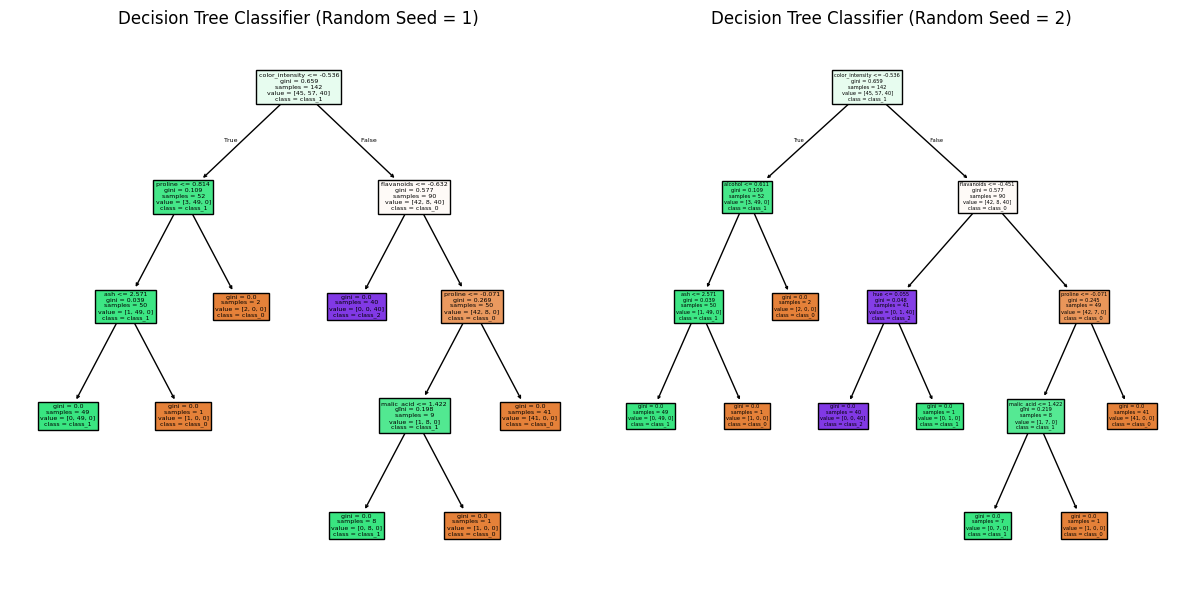

In [65]:
# We maken een prentje om ze naast elkaar weer te geven
plt.figure(figsize=(12, 6))

# Links de eerste beslissingsboom
plt.subplot(1, 2, 1)
plot_tree(clf1, feature_names=df.feature_names, class_names=df.target_names, filled=True)
plt.title("Decision Tree Classifier (Random Seed = 1)")

# Rechts de tweede beslissingsboom
plt.subplot(1, 2, 2)
plot_tree(clf2, feature_names=df.feature_names, class_names=df.target_names, filled=True)
plt.title("Decision Tree Classifier (Random Seed = 2)")

plt.tight_layout()
plt.show()

Maak nu een simpeler model met enkel de eerste twee features van de dataset en plot de decision boundaries van beide bomen naast elkaar.

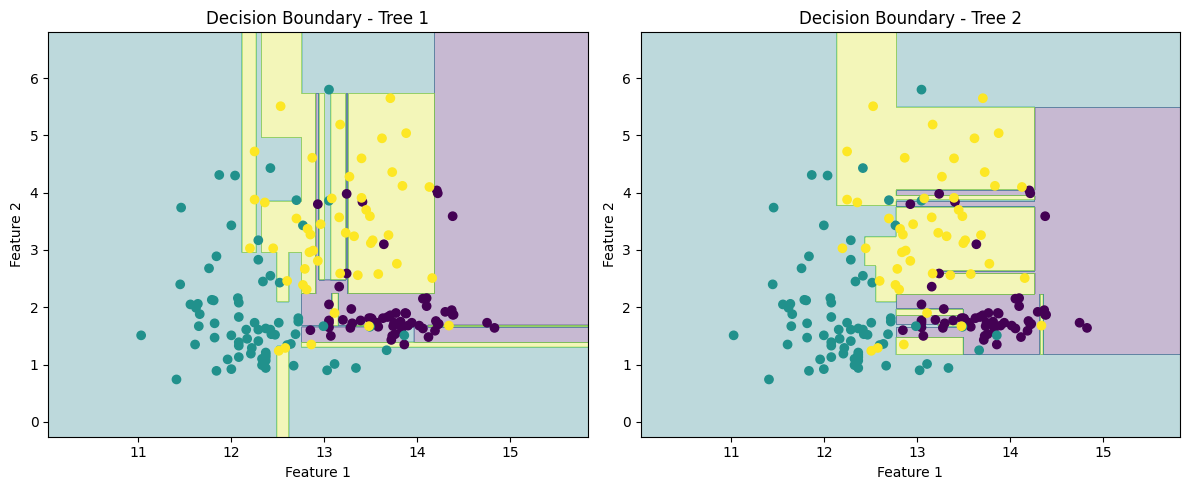

In [66]:
# TODO: laad de wine dataset opnieuw maar houd enkel de eerste twee features (X = wine.data[:, :2])
df2 = load_wine()
X,y = df2.data[:, :2], df2.target
# TODO: maak opnieuw twee splits (test_size=0.2, random_state=42 en random_state=43)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X,y,test_size=0.2,random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X,y,test_size=0.2,random_state=43)
# TODO: train clf1 en clf2 op deze (kleinere) datasets
clf1 =  DecisionTreeClassifier()
clf1.fit(X_train1,y_train1)
clf2 =  DecisionTreeClassifier()
clf2.fit(X_train2,y_train2)
# TODO: maak een meshgrid over de eerste twee features en plot de decision boundary van elke boom
#       (hint: clf.predict op de punten van het meshgrid, daarna plt.contourf)
# TODO: maak een meshgrid over de eerste twee features

# Grenzen bepalen voor de twee features
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Meshgrid maken
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Punten van het meshgrid omvormen naar (x, y)-paren
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Voorspellingen van beide decision trees
Z1 = clf1.predict(grid_points)
Z2 = clf2.predict(grid_points)

# Terug omvormen naar de vorm van het meshgrid
Z1 = Z1.reshape(xx.shape)
Z2 = Z2.reshape(xx.shape)

# Plotten
plt.figure(figsize=(12, 5))

# Decision boundary van clf1
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z1, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Boundary - Tree 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Decision boundary van clf2
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z2, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Boundary - Tree 2")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

---
# Oefening 2 — Voting classifier op de Breast Cancer dataset

- Laad de breast cancer dataset via `sklearn.datasets.load_breast_cancer()`.
- Pas een `StandardScaler` toe en splits met `test_size=0.2` en `random_state=42`.
- Maak drie classifiers: `knn_classifier = KNeighborsClassifier(5)`, `decision_tree_classifier = DecisionTreeClassifier(random_state=42)` en `svm_classifier = SVC(probability=True)`.
- Combineer ze in een `VotingClassifier` met `voting='soft'`.
- Sla de test-voorspellingen op in `y_pred_voting` en de **accuracy op de testset** in `accuracy_voting` (float).

In [67]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# TODO: laad de dataset en pas een StandardScaler toe
df = load_breast_cancer()
X,y = df.data, df.target
scaler = StandardScaler()
scaler.fit(X)
# TODO: train/test split (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# TODO: maak knn_classifier (KNeighborsClassifier(5)), decision_tree_classifier
#       (DecisionTreeClassifier(random_state=42)) en svm_classifier (SVC(probability=True))
knn_classifier = KNeighborsClassifier(n_neighbors=5)
decision_tree_classifier = DecisionTreeClassifier(random_state=42)
svm_classifier = SVC(probability=True)
#       (DecisionTreeClassifier(random_state=42))
# TODO: maak voting_classifier (VotingClassifier met voting='soft')
voting_classifier = VotingClassifier(
    estimators=[
        ('knn', knn_classifier),
        ('dt', decision_tree_classifier),
        ('svm', svm_classifier)
    ],
    voting='soft'
)
# TODO: fit, voorspel op de testset en bereken de accuracy
voting_classifier.fit(X_train, y_train)

y_pred_voting = voting_classifier.predict(X_test)
# accuracy berekenen
accuracy_voting = accuracy_score(y_test, y_pred_voting)

print(accuracy_voting)
print(accuracy_voting)

0.9736842105263158
0.9736842105263158


/opt/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


**Vraag (antwoord in `antwoord_ensemble`)**: Waarom presteert een (soft) voting classifier vaak beter dan één enkele decision tree? Kies A, B, C of D:

- A: Omdat een voting classifier de features automatisch schaalt
- B: Omdat een voting classifier meer trainingsdata gebruikt dan een enkel model
- C: Omdat fouten van de individuele modellen elkaar deels opheffen: het ensemble combineert de voorspellingen (bij soft voting via de kansen) zodat individuele fouten minder doorwegen
- D: Omdat een voting classifier nooit overfit op de trainingsdata

In [68]:
antwoord_ensemble = "C"

Pas nu de `voting_classifier` aan naar `voting='hard'` en vergelijk de accuracy met de soft voting-variant. Bekijk daarna ook de individuele performantie van de onderliggende classifiers.

In [69]:
individual_estimators = [knn_classifier, decision_tree_classifier, svm_classifier]
for estimator in individual_estimators:
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy van {estimator.__class__.__name__}: {accuracy:.4f}")

Accuracy van KNeighborsClassifier: 0.9561
Accuracy van DecisionTreeClassifier: 0.9474
Accuracy van SVC: 0.9474


/opt/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


---
# Oefening 3 — Bagging op de Wine dataset

- Laad opnieuw de wine dataset (geen scaler nodig hier) en splits met `test_size=0.2` en `random_state=42`.
- Train een `BaggingClassifier` met als base estimator een `DecisionTreeClassifier`, `n_estimators=100` en `random_state=42`.
- Train ook één enkele `DecisionTreeClassifier(random_state=42)`.
- Sla de accuracy van bagging op in `accuracy_bagging` en van de enkele boom in `accuracy_single_tree` (beide floats).

In [70]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# TODO: laad de dataset en splits (test_size=0.2, random_state=42)
wine = load_wine()
X,y = wine.data,wine.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# TODO: bagging met 100 bomen: BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42) en fit
bag = BaggingClassifier(DecisionTreeClassifier(),n_estimators=100,random_state=42)
bag.fit(X_train,y_train)
# TODO: train ook één enkele DecisionTreeClassifier(random_state=42)
dec = DecisionTreeClassifier(random_state=42)
dec.fit(X_train,y_train)
# TODO: bereken accuracy_bagging en accuracy_single_tree
y_pred_bagging = bag.predict(X_test)
y_pred_single_tree = dec.predict(X_test)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
accuracy_single_tree = accuracy_score(y_test, y_pred_single_tree)
print(accuracy_bagging, accuracy_single_tree)

0.9722222222222222 0.9444444444444444


---
# Oefening 4 — AdaBoost vs XGBoost op de Titanic dataset

Data voorbereiding (gebruik `data/titanic_dataset.csv`):
- Verwijder de kolommen `PassengerId`, `Name`, `Ticket` en `Cabin`.
- Vul ontbrekende waarden in `Age` aan met een `SimpleImputer(strategy='most_frequent')`.
- Encodeer `Sex` en `Embarked` met een `LabelEncoder`.
- Gebruik als features `['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']` en als target `Survived`.
- Splits met `test_size=0.2` en `random_state=42`.

Modellen (beide met 100 estimators en `random_state=42`):
- AdaBoost: `AdaBoostClassifier(n_estimators=100, random_state=42)` → `y_pred_ada`, en in de metriekencel: `accuracy_ada` en `f1_ada`.
- XGBoost: `XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)` → `y_pred_xgb`, en in de metriekencel: `accuracy_xgb` en `f1_xgb`.

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# data inladen
titanic = pd.read_csv("data/titanic_dataset.csv")

# TODO: verwijder de kolommen PassengerId, Name, Ticket en Cabin
titanic = titanic.drop(columns=["Name", "PassengerId", "Ticket", "Cabin"])
# TODO: vul ontbrekende waarden in Age aan met SimpleImputer(strategy='most_frequent')
imputer = SimpleImputer(strategy="most_frequent")

titanic[["Age"]] = imputer.fit_transform(titanic[["Age"]])
# TODO: encodeer Sex en Embarked met een LabelEncoder
encoder = LabelEncoder()
titanic["Sex"] = encoder.fit_transform(titanic["Sex"])
titanic["Embarked"] = encoder.fit_transform(titanic["Embarked"])
# TODO: X = de features ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare'], y = 'Survived'
X,y = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']], titanic['Survived']
# TODO: train/test split (test_size=0.2, random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### AdaBoost

In [72]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# TODO: train ada_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_classifier = AdaBoostClassifier(n_estimators=100,random_state=42)
ada_classifier.fit(X_train,y_train)
# TODO: maak voorspellingen op de testset
y_pred_ada = ada_classifier.predict(X_test)

In [73]:
# uitgebreide evaluatiemetrieken
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada)
recall_ada = recall_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)
confusion_ada = confusion_matrix(y_test, y_pred_ada)

print("AdaBoost Classifier metrieken:")
print(f"Accuracy: {accuracy_ada:.2f}")
print(f"Precision: {precision_ada:.2f}")
print(f"Recall: {recall_ada:.2f}")
print(f"F1 Score: {f1_ada:.2f}")
print("Confusion Matrix:")
print(confusion_ada)

AdaBoost Classifier metrieken:
Accuracy: 0.80
Precision: 0.76
Recall: 0.74
F1 Score: 0.75
Confusion Matrix:
[[88 17]
 [19 55]]


### XGBoost

In [74]:
# importeer de classifier. Mogelijk moet je conda omgeving aanpassen door XGBoost te installeren
from xgboost import XGBClassifier

In [75]:
# TODO: train xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_classifier = XGBClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    max_depth=3,
    random_state = 42
)
xgb_classifier.fit(X_train,y_train)
# TODO: maak voorspellingen op de testset
y_pred_xgb = xgb_classifier.predict(X_test)

In [76]:
# uitgebreide scoringsmetrieken
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
confusion_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nXGBoost Classifier Metrics:")
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1 Score: {f1_xgb:.2f}")
print("Confusion Matrix:")
print(confusion_xgb)


XGBoost Classifier Metrics:
Accuracy: 0.82
Precision: 0.82
Recall: 0.72
F1 Score: 0.76
Confusion Matrix:
[[93 12]
 [21 53]]
